# RVL-CDIP SQL queries + recreation sampling

Queryable walkthrough over the local
[`aharley/rvl_cdip`](https://huggingface.co/datasets/aharley/rvl_cdip) SQLite index
(`.venv/rvl_cdip/rvl_cdip.db`), then a **seeded stratified draw** of **60–70
documents from each of the 16 classes (label ids 0–15)** for the recreation
experiment.

**This notebook completes the sampling task:** it writes a JSONL sample set,
a machine-readable manifest, and a per-class count table under
`data/notebook_demo/rvl_cdip_recreation/`.

::: {.callout-note}
## Prerequisites
```bash
python -m src.rvl_cdip build   # ~17 MB labels → ~400k SQL rows (idempotent)
```
Images (`rvl-cdip.tar.gz`, ~38 GB) are **optional**. Sampling uses label index
rows; `image_abspath` stays null until you opt into image download.
:::

Related docs: [RVL-CDIP SQL Index](../rvl_cdip_sql.md) · CLI `python -m src.rvl_cdip --help`

## 1. Setup

In [9]:
from __future__ import annotations

import json
import logging
import random
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

CWD = Path.cwd().resolve()
# Walk up from docs/notebooks/ (or notebooks/) until pyproject.toml is found.
REPO_ROOT = next(
    (p for p in (CWD, *CWD.parents) if (p / "pyproject.toml").exists()),
    None,
)
assert REPO_ROOT is not None, f"Could not find repo root from {CWD}"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.rvl_cdip import LABEL_NAMES, RvlCdipStore, default_db_path
from src.utils.io import write_json, write_jsonl

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

DEMO = REPO_ROOT / "data" / "notebook_demo" / "rvl_cdip_recreation"
DEMO.mkdir(parents=True, exist_ok=True)

# --- Recreation knobs ---
SEED = 42
N_PER_CLASS = 65  # choose any integer in [60, 70]
assert 60 <= N_PER_CLASS <= 70, "N_PER_CLASS must be between 60 and 70 inclusive"
# None = sample across train/test/validation; or e.g. "train"
SPLIT_FILTER: str | None = None

print(f"repo:     {REPO_ROOT}")
print(f"db:       {default_db_path()}")
print(f"demo out: {DEMO}")
print(f"SEED={SEED}  N_PER_CLASS={N_PER_CLASS}  SPLIT_FILTER={SPLIT_FILTER!r}")
print(f"classes:  {len(LABEL_NAMES)} → {list(enumerate(LABEL_NAMES))}")

repo:     /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer
db:       /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/.venv/rvl_cdip/rvl_cdip.db
demo out: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/rvl_cdip_recreation
SEED=42  N_PER_CLASS=65  SPLIT_FILTER=None
classes:  16 → [(0, 'letter'), (1, 'form'), (2, 'email'), (3, 'handwritten'), (4, 'advertisement'), (5, 'scientific report'), (6, 'scientific publication'), (7, 'specification'), (8, 'file folder'), (9, 'news article'), (10, 'budget'), (11, 'invoice'), (12, 'presentation'), (13, 'questionnaire'), (14, 'resume'), (15, 'memo')]


## 2. Open the SQL index (build if empty)

`RvlCdipStore()` opens `.venv/rvl_cdip/rvl_cdip.db`. If the documents table is
empty, `build_from_labels()` downloads the split label files (~17 MB) and
ingests all ~400k rows.

In [10]:
store = RvlCdipStore()
summary = store.summary()
print(f"documents indexed: {summary['documents']:,}")
print(f"with image paths:  {summary['with_image_abspath']:,}")
print(f"built_at:          {summary.get('built_at')}")
print(f"dataset_id:        {summary.get('dataset_id')}")

if summary["documents"] == 0:
    print("Index empty — building from Hub label files (safe; no 38 GB archive)…")
    stats = store.build_from_labels()
    summary = store.summary()
    print("build stats:", stats)
    print(f"documents indexed: {summary['documents']:,}")

assert summary["documents"] > 0, (
    "RVL-CDIP index is empty. Run: python -m src.rvl_cdip build"
)

display(pd.DataFrame(summary["by_split"]))
display(pd.DataFrame(summary["by_label"]))

documents indexed: 400,000
with image paths:  0
built_at:          2026-07-23T04:26:11Z
dataset_id:        aharley/rvl_cdip


,split,n
0,test,40000
1,train,320000
2,validation,40000


,label_id,label,n
0,0,letter,25000
1,1,form,25000
2,2,email,25000
3,3,handwritten,25000
4,4,advertisement,25000
5,5,scientific report,25000
6,6,scientific publication,25000
7,7,specification,25000
8,8,file folder,25000
9,9,news article,25000


## 3. Showcase SQL queries

### 3a. Class catalog + counts

`store.labels()` and ad-hoc `store.query(...)` (SELECT-only).

,label_id,name
0,0,letter
1,1,form
2,2,email
3,3,handwritten
4,4,advertisement
5,5,scientific report
6,6,scientific publication
7,7,specification
8,8,file folder
9,9,news article


,label_id,label,n
0,0,letter,25000
1,1,form,25000
2,2,email,25000
3,3,handwritten,25000
4,4,advertisement,25000
5,5,scientific report,25000
6,6,scientific publication,25000
7,7,specification,25000
8,8,file folder,25000
9,9,news article,25000


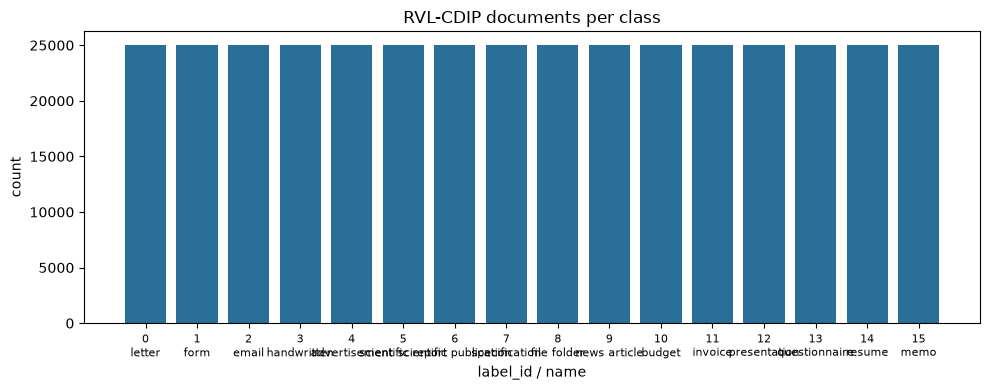

In [11]:
labels_df = pd.DataFrame(store.labels())
display(labels_df)

by_label = store.query(
    """
    SELECT d.label_id, l.name AS label, COUNT(*) AS n
    FROM documents d
    JOIN labels l ON l.label_id = d.label_id
    GROUP BY d.label_id
    ORDER BY d.label_id
    """
)
display(pd.DataFrame(by_label))

fig, ax = plt.subplots(figsize=(10, 4))
plot_df = pd.DataFrame(by_label)
ax.bar(plot_df["label_id"].astype(str) + "\n" + plot_df["label"], plot_df["n"], color="#2a6f97")
ax.set_title("RVL-CDIP documents per class")
ax.set_xlabel("label_id / name")
ax.set_ylabel("count")
plt.xticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

### 3b. Split × label heatmap-style table

Useful to see whether a class is balanced across train / test / validation.

In [12]:
split_label = store.query(
    """
    SELECT d.split, d.label_id, l.name AS label, COUNT(*) AS n
    FROM documents d
    JOIN labels l ON l.label_id = d.label_id
    GROUP BY d.split, d.label_id
    ORDER BY d.split, d.label_id
    """,
    max_rows=200,
)
pivot = (
    pd.DataFrame(split_label)
    .pivot(index=["label_id", "label"], columns="split", values="n")
    .fillna(0)
    .astype(int)
)
display(pivot)

# Example: five invoice rows from train via the list helper
invoice_train = store.list_documents(split="train", label="invoice", limit=5)
display(pd.DataFrame(invoice_train))

,split,test,train,validation
label_id,label,,,
0,letter,2464,20106,2430
1,form,2506,19957,2537
2,email,2516,19954,2530
3,handwritten,2532,20034,2434
4,advertisement,2515,19963,2522
5,scientific report,2498,19994,2508
6,scientific publication,2572,19902,2526
7,specification,2472,19997,2531
8,file folder,2527,20022,2451


,document_id,split,label_id,label,image_relpath,image_abspath,source_line
0,train:imagesr/r/l/z/rlz20d00/521107137+-7140.tif,train,11,invoice,imagesr/r/l/z/rlz20d00/521107137+-7140.tif,None,7
1,train:imagesk/k/w/s/kws90e00/91514628.tif,train,11,invoice,imagesk/k/w/s/kws90e00/91514628.tif,None,91
2,train:imagesk/k/f/z/kfz64c00/91507726_7727.tif,train,11,invoice,imagesk/k/f/z/kfz64c00/91507726_7727.tif,None,93
3,train:imagesq/q/i/z/qiz36c00/2070435354.tif,train,11,invoice,imagesq/q/i/z/qiz36c00/2070435354.tif,None,101
4,train:imagesk/k/s/v/ksv13c00/92270027_0029.tif,train,11,invoice,imagesk/k/s/v/ksv13c00/92270027_0029.tif,None,105


### 3c. Example filtered SELECTs

Same patterns as the CLI:

```bash
python -m src.rvl_cdip query "SELECT split, COUNT(*) AS n FROM documents GROUP BY split"
```

In [13]:
examples = {
    "rows_per_split": """
        SELECT split, COUNT(*) AS n
        FROM documents
        GROUP BY split
        ORDER BY split
    """,
    "handwritten_train_sample": """
        SELECT d.document_id, d.split, d.label_id, l.name AS label, d.image_relpath
        FROM documents d
        JOIN labels l ON l.label_id = d.label_id
        WHERE d.label_id = 3 AND d.split = 'train'
        ORDER BY d.source_line
        LIMIT 5
    """,
    "memo_vs_letter": """
        SELECT l.name AS label, d.split, COUNT(*) AS n
        FROM documents d
        JOIN labels l ON l.label_id = d.label_id
        WHERE d.label_id IN (0, 15)
        GROUP BY l.name, d.split
        ORDER BY l.name, d.split
    """,
}

for name, sql in examples.items():
    print(f"\n=== {name} ===")
    display(pd.DataFrame(store.query(sql)))


=== rows_per_split ===


,split,n
0,test,40000
1,train,320000
2,validation,40000



=== handwritten_train_sample ===


,document_id,split,label_id,label,image_relpath
0,train:imageso/o/e/x/oex80d00/522787731+-7732.tif,train,3,handwritten,imageso/o/e/x/oex80d00/522787731+-7732.tif
1,train:imagesn/n/t/y/nty14d00/507705676.tif,train,3,handwritten,imagesn/n/t/y/nty14d00/507705676.tif
2,train:imageso/o/v/q/ovq40d00/517303299+-3300.tif,train,3,handwritten,imageso/o/v/q/ovq40d00/517303299+-3300.tif
3,train:imagese/e/j/k/ejk41d00/515625855+-5858.tif,train,3,handwritten,imagese/e/j/k/ejk41d00/515625855+-5858.tif
4,train:imagesj/j/q/a/jqa60d00/517515626+-5627.tif,train,3,handwritten,imagesj/j/q/a/jqa60d00/517515626+-5627.tif



=== memo_vs_letter ===


,label,split,n
0,letter,test,2464
1,letter,train,20106
2,letter,validation,2430
3,memo,test,2492
4,memo,train,19975
5,memo,validation,2533


## 4. Recreation sample — 60–70 random docs per class (0–15)

For each `label_id` in `0..15`:

1. Pull candidate rows with SQL (`WHERE label_id = ?`, optional split filter)
2. Draw `N_PER_CLASS` with a **seeded** `random.Random(SEED)` (reproducible;
   SQLite `ORDER BY RANDOM()` is not seedable)
3. Tag rows with seed / n_per_class metadata

Default `N_PER_CLASS = 65` (midpoint of 60–70). Change the knob in Setup and
re-run from here.

In [14]:
def fetch_candidates(label_id: int, split: str | None = None) -> list[dict]:
    """All indexed rows for one class (optionally one split)."""
    if split:
        sql = """
            SELECT d.document_id, d.split, d.label_id, l.name AS label,
                   d.image_relpath, d.image_abspath, d.source_line
            FROM documents d
            JOIN labels l ON l.label_id = d.label_id
            WHERE d.label_id = ? AND d.split = ?
            """
        params: tuple = (label_id, split)
    else:
        sql = """
            SELECT d.document_id, d.split, d.label_id, l.name AS label,
                   d.image_relpath, d.image_abspath, d.source_line
            FROM documents d
            JOIN labels l ON l.label_id = d.label_id
            WHERE d.label_id = ?
            """
        params = (label_id,)
    # One class ≈ 25k rows — raise max_rows past the default 1000.
    return store.query(sql, params, max_rows=50_000)


def sample_recreation_set(
    *,
    n_per_class: int,
    seed: int,
    split: str | None = None,
) -> list[dict]:
    rng = random.Random(seed)
    out: list[dict] = []
    for label_id in range(len(LABEL_NAMES)):
        candidates = fetch_candidates(label_id, split=split)
        if len(candidates) < n_per_class:
            raise RuntimeError(
                f"label_id={label_id} ({LABEL_NAMES[label_id]!r}) has only "
                f"{len(candidates)} candidates; need {n_per_class}"
            )
        picked = rng.sample(candidates, n_per_class)
        for row in picked:
            item = dict(row)
            item["recreation_seed"] = seed
            item["n_per_class"] = n_per_class
            item["split_filter"] = split
            out.append(item)
    return out


samples = sample_recreation_set(
    n_per_class=N_PER_CLASS, seed=SEED, split=SPLIT_FILTER
)
sample_df = pd.DataFrame(samples)

print(f"total samples: {len(sample_df):,}  (expect {16 * N_PER_CLASS:,})")
counts = (
    sample_df.groupby(["label_id", "label"], sort=True)
    .size()
    .rename("n")
    .reset_index()
)
display(counts)
display(sample_df["split"].value_counts().rename("n").to_frame())
display(sample_df.head(8))

# Hard checks — notebook "completes" only if these pass
assert len(sample_df) == 16 * N_PER_CLASS
assert set(sample_df["label_id"]) == set(range(16))
assert (counts["n"] == N_PER_CLASS).all()
assert sample_df["document_id"].is_unique
print("✓ stratified sample OK: exactly", N_PER_CLASS, "unique docs × 16 classes")

total samples: 1,040  (expect 1,040)


,label_id,label,n
0,0,letter,65
1,1,form,65
2,2,email,65
3,3,handwritten,65
4,4,advertisement,65
5,5,scientific report,65
6,6,scientific publication,65
7,7,specification,65
8,8,file folder,65
9,9,news article,65


,n
split,
train,824
validation,112
test,104


,document_id,split,label_id,label,image_relpath,image_abspath,source_line,recreation_seed,n_per_class,split_filter
0,test:imagesz/z/p/v/zpv93d00/508330972_50833097...,test,0,letter,imagesz/z/p/v/zpv93d00/508330972_508330974.tif,None,13284,42,65,None
1,train:imagese/e/u/v/euv68e00/2001213893.tif,train,0,letter,imagese/e/u/v/euv68e00/2001213893.tif,None,57555,42,65,None
2,train:imagesp/p/s/e/pse16c00/2071710123.tif,train,0,letter,imagesp/p/s/e/pse16c00/2071710123.tif,None,13386,42,65,None
3,validation:imagesx/x/g/p/xgp60d00/522473908+-3...,validation,0,letter,imagesx/x/g/p/xgp60d00/522473908+-3908.tif,None,28603,42,65,None
4,train:imagesp/p/a/z/paz81e00/01353637_01353639...,train,0,letter,imagesp/p/a/z/paz81e00/01353637_01353639.tif,None,143445,42,65,None
5,train:imagesw/w/e/a/wea08e00/1003719841.tif,train,0,letter,imagesw/w/e/a/wea08e00/1003719841.tif,None,127504,42,65,None
6,train:imagesh/h/r/s/hrs33c00/98798570_8573.tif,train,0,letter,imagesh/h/r/s/hrs33c00/98798570_8573.tif,None,116510,42,65,None
7,train:imagesn/n/y/r/nyr28d00/2070602093_2100.tif,train,0,letter,imagesn/n/y/r/nyr28d00/2070602093_2100.tif,None,72423,42,65,None


✓ stratified sample OK: exactly 65 unique docs × 16 classes


## 5. Export artifacts for the recreation experiment

Writes under `data/notebook_demo/rvl_cdip_recreation/`:

| File | Contents |
|------|----------|
| `recreation_samples.jsonl` | One sampled document per line |
| `recreation_manifest.json` | Seed, n_per_class, counts, db path |
| `recreation_counts.csv` | Per-class counts |

In [15]:
samples_path = DEMO / "recreation_samples.jsonl"
manifest_path = DEMO / "recreation_manifest.json"
counts_path = DEMO / "recreation_counts.csv"

write_jsonl(samples_path, samples)
counts.to_csv(counts_path, index=False)

manifest = {
    "experiment": "rvl_cdip_recreation",
    "dataset_id": summary.get("dataset_id"),
    "db_path": summary.get("db_path"),
    "seed": SEED,
    "n_per_class": N_PER_CLASS,
    "n_classes": 16,
    "total_samples": len(samples),
    "split_filter": SPLIT_FILTER,
    "label_names": list(LABEL_NAMES),
    "counts_by_label_id": {
        int(r["label_id"]): int(r["n"]) for _, r in counts.iterrows()
    },
    "samples_path": str(samples_path.relative_to(REPO_ROOT)),
    "counts_path": str(counts_path.relative_to(REPO_ROOT)),
}
write_json(manifest_path, manifest)

print("wrote:", samples_path)
print("wrote:", manifest_path)
print("wrote:", counts_path)
display(Markdown(f"```json\n{json.dumps(manifest, indent=2)}\n```"))

# Reload check
reloaded = [json.loads(line) for line in samples_path.read_text().splitlines() if line.strip()]
assert len(reloaded) == len(samples)
assert Counter(r["label_id"] for r in reloaded) == Counter(
    {i: N_PER_CLASS for i in range(16)}
)
print("✓ export verified on disk")

wrote: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/rvl_cdip_recreation/recreation_samples.jsonl
wrote: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/rvl_cdip_recreation/recreation_manifest.json
wrote: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/rvl_cdip_recreation/recreation_counts.csv


```json
{
  "experiment": "rvl_cdip_recreation",
  "dataset_id": "aharley/rvl_cdip",
  "db_path": "/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/.venv/rvl_cdip/rvl_cdip.db",
  "seed": 42,
  "n_per_class": 65,
  "n_classes": 16,
  "total_samples": 1040,
  "split_filter": null,
  "label_names": [
    "letter",
    "form",
    "email",
    "handwritten",
    "advertisement",
    "scientific report",
    "scientific publication",
    "specification",
    "file folder",
    "news article",
    "budget",
    "invoice",
    "presentation",
    "questionnaire",
    "resume",
    "memo"
  ],
  "counts_by_label_id": {
    "0": 65,
    "1": 65,
    "2": 65,
    "3": 65,
    "4": 65,
    "5": 65,
    "6": 65,
    "7": 65,
    "8": 65,
    "9": 65,
    "10": 65,
    "11": 65,
    "12": 65,
    "13": 65,
    "14": 65,
    "15": 65
  },
  "samples_path": "data/notebook_demo/rvl_cdip_recreation/recreation_samples.jsonl",
  "counts_path": "data/notebook_demo/rvl_cdip_recreation/recreation_counts.csv"
}
```

✓ export verified on disk


## 6. Peek + next steps

Reload helpers for downstream recreation / OCR / classifier work.

In [16]:
# Peek one document per class
peek = (
    sample_df.sort_values(["label_id", "document_id"])
    .groupby("label_id", as_index=False)
    .first()[["label_id", "label", "split", "document_id", "image_relpath"]]
)
display(peek)

# Optional: resolve a single row through the store API
example_id = samples[0]["document_id"]
print("store.get_document:", store.get_document(example_id))

display(
    Markdown(
        f"""
**Done.** Recreation set ready:

- `{samples_path.relative_to(REPO_ROOT)}` — {len(samples)} rows
- `{manifest_path.relative_to(REPO_ROOT)}` — seed={SEED}, n_per_class={N_PER_CLASS}

CLI equivalents:
```bash
python -m src.rvl_cdip summary
python -m src.rvl_cdip query "SELECT label_id, COUNT(*) AS n FROM documents GROUP BY label_id"
```
"""
    )
)

,label_id,label,split,document_id,image_relpath
0,0,letter,test,test:imagesg/g/n/y/gny54a00/89989717.tif,imagesg/g/n/y/gny54a00/89989717.tif
1,1,form,test,test:imagesb/b/v/c/bvc73e00/2024795599.tif,imagesb/b/v/c/bvc73e00/2024795599.tif
2,2,email,test,test:imagesb/b/z/k/bzk82a00/527929946+-9947.tif,imagesb/b/z/k/bzk82a00/527929946+-9947.tif
3,3,handwritten,test,test:imagesb/b/p/b/bpb80d00/517686892+-6894.tif,imagesb/b/p/b/bpb80d00/517686892+-6894.tif
4,4,advertisement,test,test:imagesh/h/o/z/hoz42f00/tob14423.32.tif,imagesh/h/o/z/hoz42f00/tob14423.32.tif
5,5,scientific report,test,test:imagesd/d/a/h/dah18e00/1001766862_1001766...,imagesd/d/a/h/dah18e00/1001766862_1001766864.tif
6,6,scientific publication,test,test:imagesb/b/a/g/bag59c00/PUBLICATIONS035819...,imagesb/b/a/g/bag59c00/PUBLICATIONS035819-5.tif
7,7,specification,test,test:imagesf/f/c/a/fca81a00/2057483292_2057483...,imagesf/f/c/a/fca81a00/2057483292_2057483295.tif
8,8,file folder,test,test:imagesb/b/x/u/bxu70a00/0060162220.tif,imagesb/b/x/u/bxu70a00/0060162220.tif
9,9,news article,test,test:imagesa/a/c/z/acz91c00/2080718792.tif,imagesa/a/c/z/acz91c00/2080718792.tif


store.get_document: {'document_id': 'test:imagesz/z/p/v/zpv93d00/508330972_508330974.tif', 'split': 'test', 'label_id': 0, 'image_relpath': 'imagesz/z/p/v/zpv93d00/508330972_508330974.tif', 'image_abspath': None, 'source_line': 13284, 'metadata_json': '{}', 'created_at': 1784780769.0625181, 'label': 'letter'}



**Done.** Recreation set ready:

- `data/notebook_demo/rvl_cdip_recreation/recreation_samples.jsonl` — 1040 rows
- `data/notebook_demo/rvl_cdip_recreation/recreation_manifest.json` — seed=42, n_per_class=65

CLI equivalents:
```bash
python -m src.rvl_cdip summary
python -m src.rvl_cdip query "SELECT label_id, COUNT(*) AS n FROM documents GROUP BY label_id"
```
